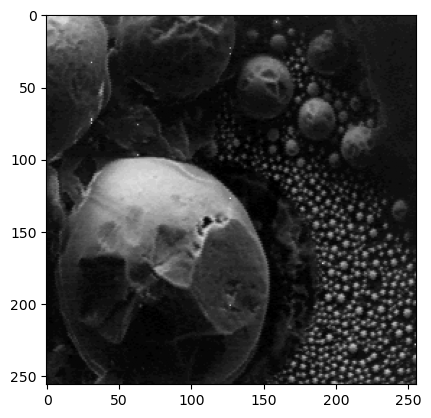

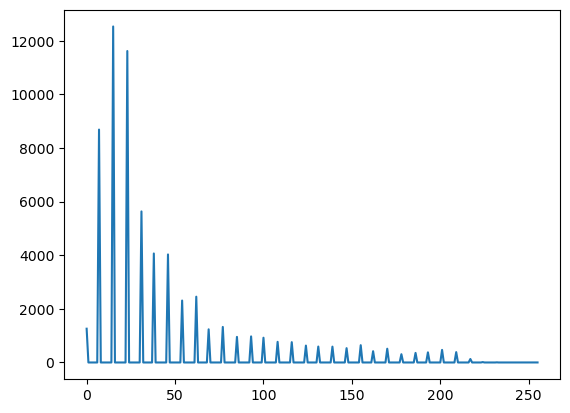

Niveles de gris donde hay picos:
[  7  15  23  31  38  46  54  62  69  77  85  93 100 108 116 124 131 139
 147 155 162 170 178 186 193 201 209 217 224 232 240 248]


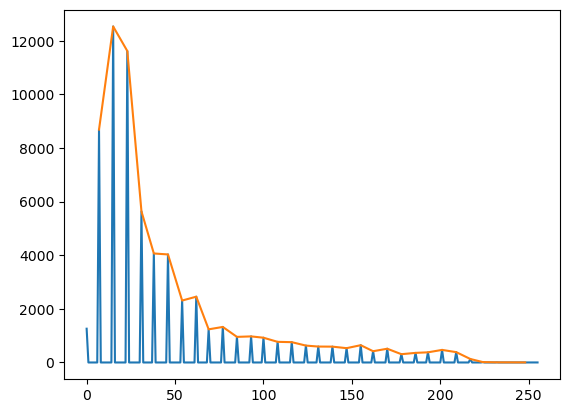

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

image = cv2.imread("images/MEB.png", cv2.IMREAD_GRAYSCALE)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.show()

# Visualizar histograma
hist = cv2.calcHist([image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

# Encontrar picos
hist = hist.flatten()
peaks, properties = find_peaks(hist, height=0)
print("Niveles de gris donde hay picos:")
print(peaks)

# Visualizar
plt.plot(hist)
plt.plot(peaks, hist[peaks])
plt.show()

Describa su forma: ¿es continuo/discontinuo?, ¿cuántos niveles de gris diferentes tiene?,
¿cuáles son estos niveles de gris?

Su forma es discontinua, tiene diferentes picos en diferentes niveles de gris. Tiene 32 picos de gris. Y los niveles de gris son los siguientes:
[  7  15  23  31  38  46  54  62  69  77  85  93 100 108 116 124 131 139
 147 155 162 170 178 186 193 201 209 217 224 232 240 248]


Partiendo del histograma, deduzca con cuántos bits ha sido numerizada esta imagen.
Si el rango va de 0 - 255, la imagen es de 8 bits

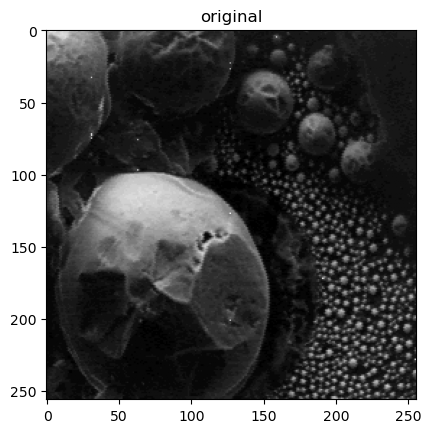

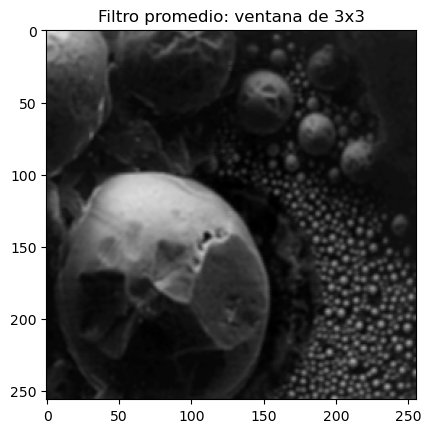

In [14]:
#Aplique un filtro promedio utilizando una máscara de tamaño 3x3 a esta imagen.
from skimage.morphology import footprint_rectangle
from skimage.filters.rank import mean

avg = mean(image, footprint_rectangle((3,3)))

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.title("original")
plt.show()

# Visualizar imagen
plt.imshow(avg, cmap="gray",  vmin=0, vmax=255)
plt.title("Filtro promedio: ventana de 3x3")
plt.show()

¿cómo es la imagen resultado?
La imagen resultado esta mucho mas difuminada, me parece que pierde detalle

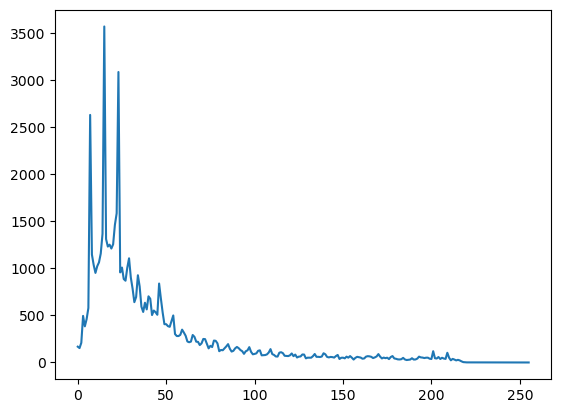

Niveles de gris donde hay picos:
[  3   7  15  18  23  25  29  34  38  40  43  46  54  59  65  71  75  77
  81  85  90  97 103 109 115 121 123 127 134 139 143 147 150 152 154 158
 164 170 173 175 178 184 189 193 197 201 204 206 209 212 215 226 229 232
 236]


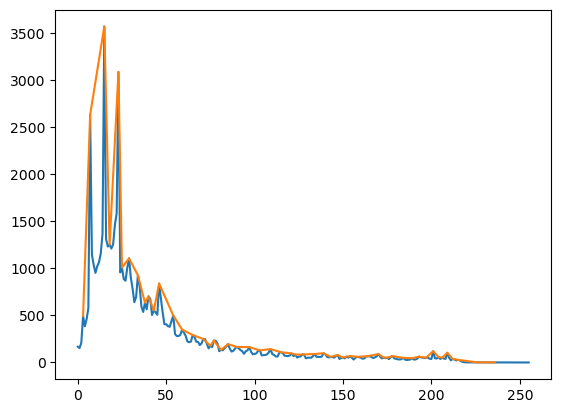

In [16]:
#Visualice el histograma de esta nueva imagen, y compárelo con el histograma de la imagen original (forma general, altura de los picos, ...).
# Visualizar histograma
hist = cv2.calcHist([avg],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

# Encontrar picos
hist = hist.flatten()
peaks, properties = find_peaks(hist, height=0)
print("Niveles de gris donde hay picos:")
print(peaks)

# Visualizar
plt.plot(hist)
plt.plot(peaks, hist[peaks])
plt.show()

Comparacion con el histograma anterior:
Tiene mas picos de grises, al suavizar la imagen se pueden generar mas valores intermedios en donde estaban las discontinuidades del histograma anterior. Esto esta generando pequeñas variaciones en el histograma, esto hace que aparezcan muchos máximos locales pequeños

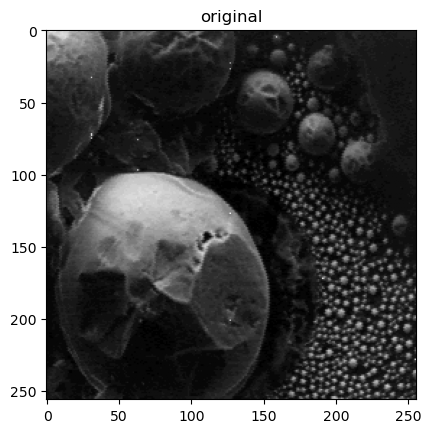

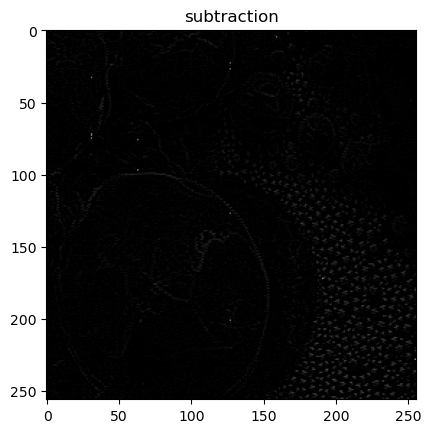

In [19]:
#Calcule la imagen de diferencia con la original
import cv2

subtraction = cv2.subtract(image, avg)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.title("original")
plt.show()

# Visualizar imagen
plt.imshow(subtraction, cmap="gray",  vmin=0, vmax=255)
plt.title("subtraction")
plt.show()

Justifique el resultado obtenido (¿en cuáles regiones de la imagen son visibles las diferencias?, ¿por qué?)

La resta entre la imagen original y la imagen suavizada con filtro promedio resalta principalmente las regiones donde existen cambios bruscos de intensidad, como los bordes del objeto y las zonas con textura (por ejemplo, el patrón punteado). Esto ocurre porque el filtro promedio elimina las componentes de baja frecuencia (zonas homogéneas), al restarlas de la imagen original, permanecen únicamente los componentes de alta frecuencia. En las regiones uniformes casi no se observan diferencias, ya que el suavizado no modifica significativamente esos píxeles.

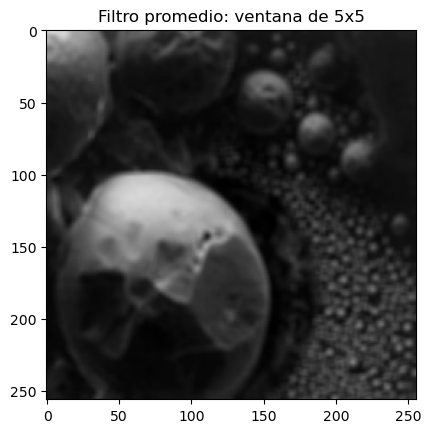

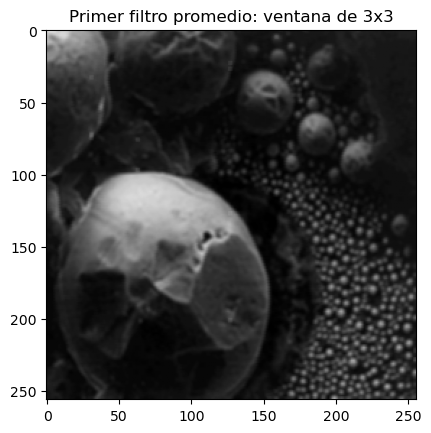

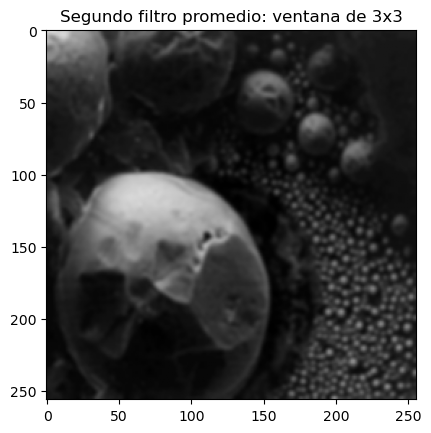

In [24]:
#Ahora filtre la imagen original con un filtro promedio utilizando una máscara de tamaño 5x5. Paralelamente, filtre la imagen original, aplicando consecutivamente sobre esta, dos filtros promedio de tamaño 3x3.

avg = mean(image, footprint_rectangle((5,5)))

# Visualizar imagen
plt.imshow(avg, cmap="gray",  vmin=0, vmax=255)
plt.title("Filtro promedio: ventana de 5x5")
plt.show()

avg2 = mean(image, footprint_rectangle((3,3)))
avg3 = mean(avg2, footprint_rectangle((3,3)))

# Visualizar imagen
plt.imshow(avg2, cmap="gray",  vmin=0, vmax=255)
plt.title("Primer filtro promedio: ventana de 3x3")
plt.show()

# Visualizar imagen
plt.imshow(avg3, cmap="gray",  vmin=0, vmax=255)
plt.title("Segundo filtro promedio: ventana de 3x3")
plt.show()

Haga una evaluación visual de los resultados: ¿las dos imágenes obtenidas son idénticas? ¿por qué? ¿cuál de los dos tratamientos suprime mejor los cambios de nivel de gris de la imagen?

No me parece que sean identicas, la imagen de ventana 5x5 esta sutilmente mas difuminada comparada con la que se le aplico doble suavizado de 3x3. Se ve mejor en la que se aplicó el doble filtro.

Convolucionar una imagen dos veces con una misma máscara equivale a hacer una sola convolución con otra máscara, obtenida por convolución de la máscara inicial con ella misma. ¿Cuál es entonces la máscara resultante de la convolución de la máscara del filtro promedio 3x3 con ella misma? ¿Cómo es la máscara del filtro promedio 5x5? Con base en la forma de estas dos máscaras, justifique los resultados visuales obtenidos en el punto anterior.

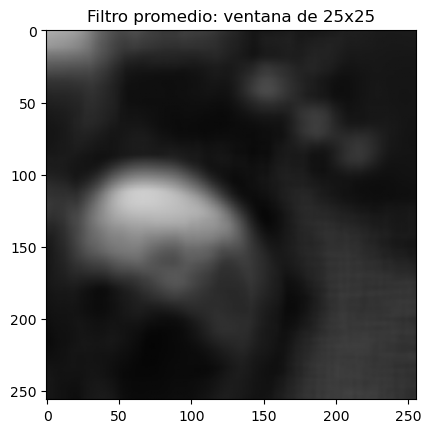

In [26]:
#Por último, filtre la imagen original con un filtro promedio utilizando una máscara de tamaño 25x25
avg = mean(image, footprint_rectangle((25,25)))

# Visualizar imagen
plt.imshow(avg, cmap="gray",  vmin=0, vmax=255)
plt.title("Filtro promedio: ventana de 25x25")
plt.show()


Haga una evaluación visual del resultado: ¿qué objetos de la imagen original se conservaron?¿qué sucedió con las estructuras pequeñas presentes en la imagen original?¿por qué?

La imagen conserva los objetos mas grandes, a medida que se aumenta el tamaño de la ventana, vamos perdiendo los objetos mas pequeños de la imagen.

Comparación entre el filtro promedio y el filtro gaussiano

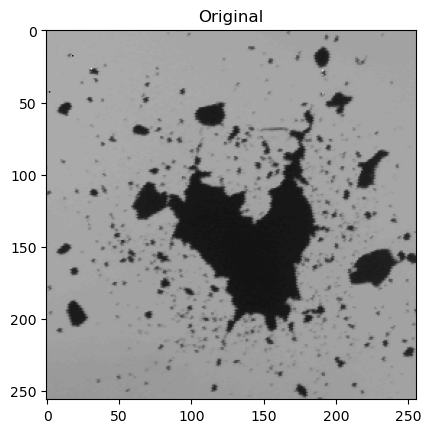

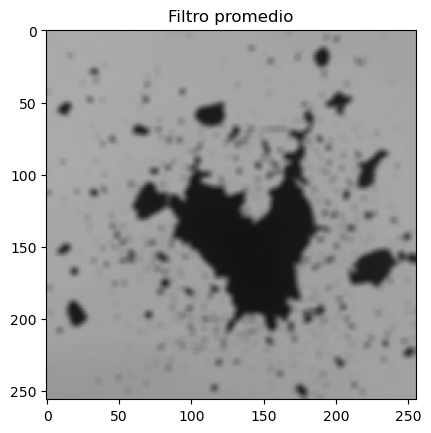

In [31]:
#Aplique a esta imagen un filtro promedio con una máscara de tamaño 5x5 usando una convolución. Visualice el resultado.
image = cv2.imread("images/impact.png", cv2.IMREAD_GRAYSCALE)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.title("Original")
plt.show()

avg = mean(image, footprint_rectangle((5,5)))

# Visualizar imagen
plt.imshow(avg, cmap="gray",  vmin=0, vmax=255)
plt.title("Filtro promedio")
plt.show()

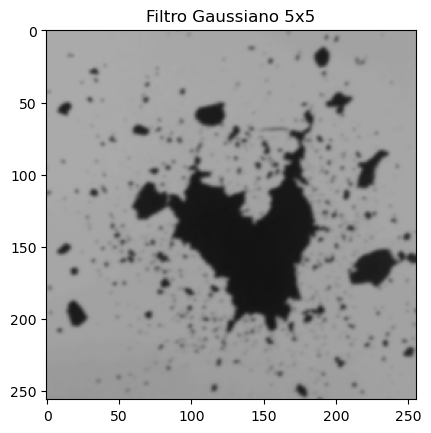

In [ ]:
#Ahora aplique a la imagen original un filtro gaussiano con una máscara de tamaño 5x5 usando una convolución. Visualice el resultado.
# Aplique un filtro Gaussiano con varianza en 0 a la imagen. Visualice el resultado.
from skimage.filters import gaussian
from skimage.filters import laplace

img_gaus = gaussian(image, sigma=1, preserve_range=True) #Sigma = 1 es un kernel de 5x5 o 0.67 aproximadamente

plt.imshow(img_gaus, cmap="gray", vmin=0, vmax=255)
plt.title("Filtro Gaussiano 5x5")
plt.show()

uint8
float64


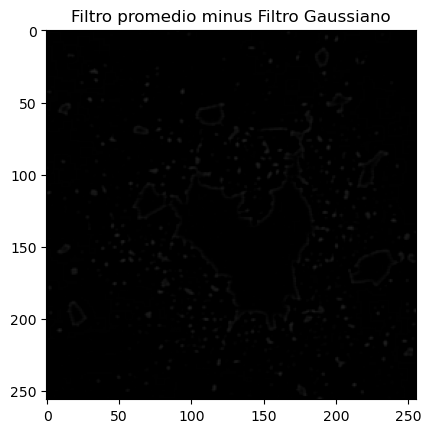

In [37]:
#Calcule la diferencia de los resultados de los dos filtros. Visualice el resultado.
print(avg.dtype)
print(img_gaus.dtype)
subtraction = cv2.subtract(avg, img_gaus.astype(np.uint8))

plt.imshow(subtraction, cmap="gray", vmin=0, vmax=255)
plt.title("Filtro promedio minus Filtro Gaussiano")
plt.show()

Justifique el resultado obtenido (¿en cuáles regiones de la imagen son visibles las diferencias?, ¿por qué?...).

En las regiones de los objetos mas pequeños es donde se ven las diferencias.

¿ En qué casos (características de las imágenes) preferiría utilizar un filtro promedio a un filtro gaussiano y visceversa?

El filtro promedio es adecuado cuando se desea un suavizado simple y uniforme en imágenes con ruido leve, aunque tiende a difuminar los bordes. En cambio, el filtro gaussiano es preferible cuando se desea reducir ruido preservando mejor las estructuras y bordes de la imagen, ya que asigna mayor peso a los píxeles centrales y produce un suavizado más progresivo y natural.